In [1]:
import sys
sys.path.append('../')

In [2]:
import Hamiltonian as ham
import scipy.sparse as sp
import numpy as np
from matplotlib import pyplot as plt
import Evolution as evol

In [3]:
def fidelity_pure(psi,phi):
    '''
    input values should be column vectors
    '''
    F=np.abs(psi.conj().T@phi)**2
    return F[0,0]

def variance(psi,H):
    V=np.real((psi.conj().T@H@H@psi)-(psi.conj().T@H@psi)**2)
    return V[0,0]


In [4]:
from qrisp.operators import X, Y, Z

def TFIM_qr(J,h,n_qubits):
    H = 0
    for i in range(n_qubits):
        i_next = (i+1)%n_qubits
        H += J*Z(i)*Z(i_next) + h*X(i)
    return H

def H_0(J,n_qubits):
    H = 0
    for i in range(0,n_qubits,2):
        H += J*Z(i)*Z((i+1)%n_qubits)
    return H

def H_1(J,n_qubits):
    H = 0
    for i in range(1,n_qubits,2):
        H += J*Z(i)*Z((i+1)%n_qubits)
    return H

def H_2(h,n_qubits):
    H = 0
    for i in range(n_qubits):
        H += h*X(i)
    return H

/home/luca/Documents/QITE-UV/Qite/lib/python3.12/site-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.1 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


In [ ]:
from qrisp.vqe import VQEProblem
from qrisp import QuantumVariable,x
from qrisp import h as h_gate

n_qubits=8
J=0.5
h=1
H = TFIM_qr(J,h,n_qubits)

print('Computing Eigs')
EH,VH = np.linalg.eigh(H.to_array())
psigs=VH[:,0:1]
E_gs=EH[0]

def exp_H(qv,t):
    # Applies 5 Trotter steps of the Hamiltonian evolution
    H.trotterization(method='commuting')(qv, t, 1)

def ansatz_hva(qv,params):
    # HVA ansatz with 3 parameters, one for each term of the Hamiltonian
    H_0(J,n_qubits).trotterization(method='commuting')(qv, t=params[0])
    H_1(J,n_qubits).trotterization(method='commuting')(qv, t=params[1])
    H_2(h,n_qubits).trotterization(method='commuting')(qv, t=params[2])

def init_function(qv):
    for i in range(0,n_qubits,2):
        x(qv[i])


def U_0(qv):
    pass

HVA = VQEProblem(H,ansatz_hva,3,init_function=init_function)
U_HVA = HVA.train_function(QuantumVariable(n_qubits),depth=3,max_iter=100)

def state_prep_hva():
    qv = QuantumVariable(n_qubits)
    U_HVA(qv)
    return qv


Computing Eigs


In [21]:
# Inspect VQE training and produced circuit
from run_qite import get_statevector
import inspect

print('HVA type:', type(HVA))
candidates = ['opt_result','opt_params','optimal_parameters','result','params','best_params','theta','optimal_theta']
for name in candidates:
    if hasattr(HVA, name):
        print(f'HVA.{name}:', getattr(HVA, name))

print('U_HVA callable:', callable(U_HVA))
try:
    qv = QuantumVariable(n_qubits)
    U_HVA(qv)
    qc = qv.qs.compile()
    print('Compiled HVA circuit ops:', qc.count_ops())
    print('Circuit depth:', qc.depth())
    sv = get_statevector(qc, n_qubits)
    print('HVA fidelity to ground state:', fidelity_pure(psigs, sv.reshape(-1,1)))
except Exception as e:
    print('Error inspecting U_HVA:', e)

# Show some metadata about the returned train function (closure types)
try:
    if hasattr(U_HVA, '__closure__') and U_HVA.__closure__:
        print('U_HVA closure types:', [type(c.cell_contents) for c in U_HVA.__closure__])
    print('U_HVA source available:', hasattr(U_HVA, '__code__'))
except Exception:
    pass


HVA type: <class 'qrisp.algorithms.vqe.vqe_problem.VQEProblem'>
U_HVA callable: True
Compiled HVA circuit ops: {'x': 4, 'cx': 48, 'rz': 48, 'h': 48}
Circuit depth: 28
HVA fidelity to ground state: 0.16719271477069197                               
U_HVA closure types: [<class 'int'>, <class 'numpy.ndarray'>, <class 'qrisp.algorithms.vqe.vqe_problem.VQEProblem'>]
U_HVA source available: True


In [7]:
from run_qite import run_QITE

s_values = np.linspace(0.01, 1.5, 20)
steps = 5
results = []
results.append(run_QITE(H, U_HVA, exp_H, s_values, steps,use_statevectors=True))
results.append(run_QITE(H, U_0, exp_H, s_values, steps,use_statevectors=True))

Simulating 8 qubits.. |                                                 | [  0%]

Step 1/5...                                                                     
Step 2/5...                                                                     
Step 3/5...                                                                     
Step 4/5...                                                                     
Step 5/5...                                                                     
Step 1/5...                                                                     
Step 2/5...                                                                     
Step 3/5...                                                                     
Step 4/5...                                                                     
Step 5/5...                                                                     


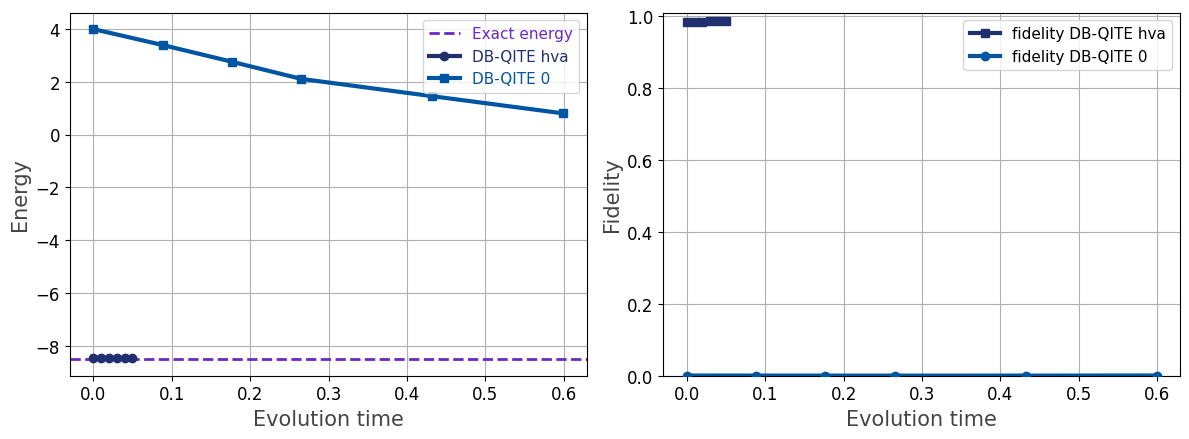

In [8]:
import matplotlib.pyplot as plt
import numpy as np

fidelities_hva = [fidelity_pure(psigs, results[0]['statevectors'][k].reshape(-1,1)) for k in range(steps+1)]
fidelities_0 = [fidelity_pure(psigs, results[1]['statevectors'][k].reshape(-1,1)) for k in range(steps+1)]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Energy plot
ax1.set_xlabel('Evolution time', fontsize=15, color='#444444')
ax1.set_ylabel('Energy', fontsize=15, color='#444444')
ax1.axhline(y=E_gs, color='#6929C4', linestyle='--', linewidth=2, label='Exact energy')
ax1.plot(results[0]['evolution_times'], results[0]['optimal_energies'], c='#20306f', marker='o', linestyle='solid', linewidth=3, zorder=3, label='DB-QITE hva')
ax1.plot(results[1]['evolution_times'], results[1]['optimal_energies'], c='#0055a3', marker='s', linestyle='solid', linewidth=3, zorder=3, label='DB-QITE 0')
ax1.legend(fontsize=11, labelcolor='linecolor')
ax1.tick_params(axis='both', labelsize=12)
ax1.grid()

# Fidelity plot
ax2.set_xlabel('Evolution time', fontsize=15, color='#444444')
ax2.set_ylabel('Fidelity', fontsize=15, color='#444444')
ax2.plot(results[0]['evolution_times'], fidelities_hva, c='#20306f', marker='s', linestyle='solid', linewidth=3, zorder=3, label='fidelity DB-QITE hva')
ax2.plot(results[1]['evolution_times'], fidelities_0, c='#0055a3', marker='o', linestyle='solid', linewidth=3, zorder=3, label='fidelity DB-QITE 0')
ax2.set_ylim(0.0, 1.01)
ax2.legend(fontsize=11)
ax2.tick_params(axis='both', labelsize=12)
ax2.grid()

plt.savefig(f'TFIM_N{n_qubits}_J{J}_h{h}_steps{steps}_DBF_results.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [9]:
results[0]['circuit_data']

[{0: {'u3': 70, 'cz': 48},
  1: {'u3': 307, 'cz': 209},
  2: {'u3': 996, 'cz': 682},
  3: {'u3': 3021, 'cz': 2079},
  4: {'u3': 9010, 'cz': 6212},
  5: {'u3': 26933, 'cz': 18520}},
 {0: 8, 1: 10, 2: 10, 3: 10, 4: 10, 5: 10},
 {0: 25, 1: 161, 2: 565, 3: 1765, 4: 5337, 5: 16037}]

In [10]:
import Hamiltonian as ham
import Evolution as evol
from run_qite import get_statevector

H_acq,H_trot=ham.TFIM(J,h,n_qubits,T=2)

#initial state
psi0np=np.zeros((2**n_qubits,1),dtype=complex)
psi0np[0]=1
psi_0=sp.csc_matrix(psi0np/np.linalg.norm(psi0np))

qc_hva = state_prep_hva().qs.compile()
psi_0_hva = sp.csc_matrix(get_statevector(qc_hva,n_qubits).reshape(-1,1))

#QITE and ACQ evolution
D=2
dt = 0.1
N = 100
print("Computing ACQ")
E_ACQ_hva,psi_ACQ_hva,indx_acq_hva,times_acq_hva,a_acq_hva = evol.ACQ(n_qubits,H_acq,H_trot,D,psi_0_hva,N,dt,methodLS='LU')
E_ACQ_0,psi_ACQ_0,indx_acq_0,times_acq_0,a_acq_0 = evol.ACQ(n_qubits,H_acq,H_trot,D,psi_0,N,dt,methodLS='LU')

Simulating 8 qubits.. |                                                 | [  0%]

Computing ACQ                                                                   
Using General Pauli Strings
Computing U at step 0
Energy doubly increased, stopping criteria activated at step 1
Using Real Pauli Strings
Computing U at step 0
Computing U at step 8
Computing U at step 9
Energy doubly increased, stopping criteria activated at step 10


In [11]:
import PauliStrings as ps
from run_qite import build_acq_circuit_qrisp

num_paulis,PD,fail = ps.real(H_trot,D,n_qubits,PDstr=True)
circuit_ops_0 = {}
circuits_0 = {}

steps_acq_0 = len(a_acq_0)
steps_acq_hva = len(a_acq_hva)

for step in range(steps_acq_0+1): 
    qc = build_acq_circuit_qrisp(n_qubits,D,2,PD,a_acq_0,times_acq_0,step,U_0)
    tqc = qc.transpile(basis_gates=['cz','u'])

    circuits_0[step] = qc
    circuit_ops_0[step] = tqc.count_ops()

circuit_data_0 = {
    'circuits': circuits_0,
    'circuit_ops': circuit_ops_0
}

circuit_ops_hva = {}
circuits_hva = {}

for step_acq in range(steps_acq_hva+1):
    qc = build_acq_circuit_qrisp(n_qubits,D,2,PD,a_acq_hva,times_acq_hva,step_acq,U_HVA,atol=1e-5)
    tqc = qc.transpile(basis_gates=['cz','u'])

    circuits_hva[step_acq] = qc
    circuit_ops_hva[step_acq] = tqc.count_ops()

circuit_data_hva = {
    'circuits': circuits_hva,
    'circuit_ops': circuit_ops_hva
}



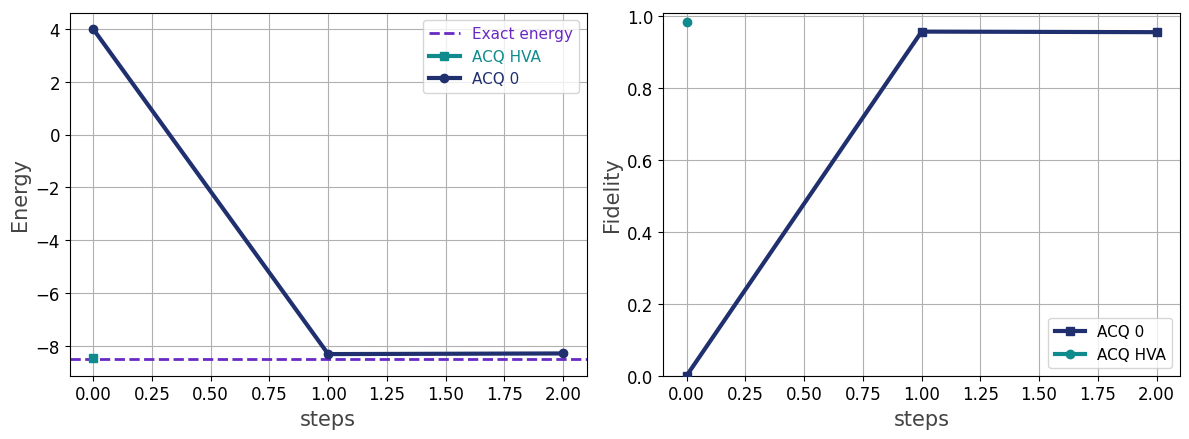

In [12]:
from run_qite import get_statevector,compute_moments

energies_acq_0 = [compute_moments(get_statevector(circuit_data_0['circuits'][step],n_qubits),H_acq)[0] for step in range(steps_acq_0+1)]
fidelities_acq_0 = [fidelity_pure(psigs, get_statevector(circuit_data_0['circuits'][step],n_qubits).reshape(-1,1)) for step in range(steps_acq_0+1)]

energies_acq_hva = [compute_moments(get_statevector(circuit_data_hva['circuits'][step],n_qubits),H_acq)[0] for step in range(steps_acq_hva+1)]
fidelities_acq_hva = [fidelity_pure(psigs, get_statevector(circuit_data_hva['circuits'][step],n_qubits).reshape(-1,1)) for step in range(steps_acq_hva+1)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
# Energy plot
ax1.set_xlabel('steps', fontsize=15, color='#444444')
ax1.set_ylabel('Energy', fontsize=15, color='#444444')
ax1.axhline(y=E_gs, color='#6929C4', linestyle='--', linewidth=2, label='Exact energy')
ax1.plot(range(steps_acq_hva+1), energies_acq_hva, c='#0f8b8d', marker='s', linestyle='solid', linewidth=3, zorder=3, label='ACQ HVA')
ax1.plot(range(steps_acq_0+1), energies_acq_0, c='#20306f', marker='o', linestyle='solid', linewidth=3, zorder=3, label='ACQ 0')
ax1.legend(fontsize=11, labelcolor='linecolor')
ax1.tick_params(axis='both', labelsize=12)
ax1.grid()

# Fidelity plot
ax2.set_xlabel('steps', fontsize=15, color='#444444')
ax2.set_ylabel('Fidelity', fontsize=15, color='#444444')
ax2.plot(range(steps_acq_0+1), fidelities_acq_0, c='#20306f', marker='s', linestyle='solid', linewidth=3, zorder=3, label='ACQ 0')
ax2.plot(range(steps_acq_hva+1), fidelities_acq_hva, c='#0f8b8d', marker='o', linestyle='solid', linewidth=3, zorder=3, label='ACQ HVA')
ax2.set_ylim(0.0, 1.01)
ax2.legend(fontsize=11, loc='upper right')
ax2.set_ylim(0.0, 1.01)
ax2.legend(fontsize=11)
ax2.tick_params(axis='both', labelsize=12)
ax2.grid()

#plt.savefig(f'TFIM_N{n_qubits}_J{J}_h{h}_steps{steps_acq_0}_ACQ_D{D}_results.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [13]:
circuit_data['circuit_ops']

NameError: name 'circuit_data' is not defined